In [1]:
from pathlib import Path
import sys
import os
import numpy as np


try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive") # mount the drive
    DATA_PATH = Path("/content/drive/MyDrive") # the root of the drive
    DATA_ROOT = DATA_PATH / "cbc_pe_data" # the root of the data
else:
    PROJECT_ROOT = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_ROOT))
    DATA_ROOT = PROJECT_ROOT / "data"


DATA_RAW = DATA_ROOT / "raw" # the root of the raw data
DATA_PROCESSED = DATA_ROOT / "processed" # the root of the processed data
MODELS_DIR = DATA_ROOT / "models" # the root of the models
RESULTS_DIR = DATA_ROOT / "results" # the root of the results
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" # the root of the checkpoints

for path in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DATA_RAW:", DATA_RAW)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("CHECKPOINTS_DIR:", CHECKPOINTS_DIR)



#Clone the repository if it doesn't exist
if IN_COLAB:
    REPO_ROOT = Path("/content/Gravitational-Waves-Lab")
    PROJECT_ROOT = REPO_ROOT / "cbc_pe"

    if not REPO_ROOT.exists():
        !git clone https://github.com/victorsh13/Gravitational-Waves-Lab.git /content/Gravitational-Waves-Lab

    print("REPO_ROOT exists:", REPO_ROOT.exists())
    print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())

    #Pull the latest version of the repository
    %cd /content/Gravitational-Waves-Lab
    !git pull
    !git status

    #Go to the project root
    %cd /content/Gravitational-Waves-Lab/cbc_pe
else:
    %cd /home/victor/gw/cbc_pe
    


# Add the project root to the python path
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("sys.path[:3]:", sys.path[:3])

Mounted at /content/drive
DATA_ROOT: /content/drive/MyDrive/cbc_pe_data
DATA_RAW: /content/drive/MyDrive/cbc_pe_data/raw
MODELS_DIR: /content/drive/MyDrive/cbc_pe_data/models
RESULTS_DIR: /content/drive/MyDrive/cbc_pe_data/results
CHECKPOINTS_DIR: /content/drive/MyDrive/cbc_pe_data/models/checkpoints
Cloning into '/content/Gravitational-Waves-Lab'...
remote: Enumerating objects: 394, done.
remote: Counting objects: 100% (291/291), done.
remote: Compressing objects: 100% (203/203), done.
remote: Total 394 (delta 165), reused 201 (delta 84), pack-reused 103 (from 1)
Receiving objects: 100% (394/394), 67.17 MiB | 30.76 MiB/s, done.
Resolving deltas: 100% (192/192), done.
REPO_ROOT exists: True
PROJECT_ROOT exists: True
/content/Gravitational-Waves-Lab
Already up to date.
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
/content/Gravitational-Waves-Lab/cbc_pe
cwd: /content/Gravitational-Waves-Lab/cbc_pe
sys.path[:3]: ['/content/Gravitation

In [ ]:
from pathlib import Path
import numpy as np

from src.io import load_dataset_npz

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n15000_merged"

dataset_path = DATA_PROCESSED / f"{dataset_id}.npz"
split_paths = sorted(DATA_PROCESSED.glob(f"{dataset_id}_splits*.npz"))

if len(split_paths) == 0:
    raise FileNotFoundError(f"No split files found for dataset_id={dataset_id}")

if len(split_paths) > 1:
    raise ValueError(
        "More than one split file found:\n"
        + "\n".join(str(p) for p in split_paths)
    )

split_path = split_paths[0]

print("Using split file:", split_path)

splits = np.load(split_path)

train_idx = splits["train_idx"]
val_idx = splits["val_idx"]

print(split_path)

batch = load_dataset_npz(dataset_path)

X = batch.X
y = batch.y
metadata = batch.metadata
network_snrs = np.array([ m["snr"]["final_network_snr"] for m in metadata], dtype=np.float32)
label_names = ["chirp_mass", "total_mass", "chi_eff"]

X_train, y_train_phys = X[train_idx], y[train_idx]
X_val, y_val_phys = X[val_idx], y[val_idx]


Using split file: /content/drive/MyDrive/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n15000_merged_splits_train12000_val3000_seed123.npz
/content/drive/MyDrive/cbc_pe_data/processed/bbh_processed_4s_seobnrv4opt_snr10-25_n15000_merged_splits_train12000_val3000_seed123.npz


In [4]:
label_stats_paths = sorted(DATA_PROCESSED.glob(f"{dataset_id}_label_stats*.npz"))

if len(label_stats_paths) == 0:
    raise FileNotFoundError(f"No label stats found for dataset_id={dataset_id}")

if len(label_stats_paths) > 1:
    raise ValueError(
        "More than one label stats file found:\n"
        + "\n".join(str(p) for p in label_stats_paths)
    )

label_stats_path = label_stats_paths[0]

y_params = np.load(label_stats_path)

y_mean = y_params["y_mean"]
y_std = y_params["y_std"]

y_train_std = (y_train_phys - y_mean) / y_std
y_val_std = (y_val_phys - y_mean) / y_std


## Datasets and Dataloaders

In [9]:
from torch.utils.data import DataLoader
from src.models.dataset import ArrayRegressionDataset

batch_size = 64

train_dataset = ArrayRegressionDataset(X_train, y_train_std)
val_dataset = ArrayRegressionDataset(X_val, y_val_std)


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)


## Load the checkpoint

In [5]:
import torch
from src.models.network import SimpleCNN, SimpleCNN_v2, SimpleCNN_Pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n15000_merged_SimpleCNN_MSELoss_emb64_seed123"

checkpoint_file_name = f"{checkpoint_id}_checkpoint.pt"
checkpoint_path = CHECKPOINTS_DIR / checkpoint_file_name

checkpoint = torch.load(checkpoint_path, map_location=device)

model_config = checkpoint["model_config"]

model = SimpleCNN(
    n_detectors=model_config["n_detectors"],
    n_outputs=model_config["n_outputs"],
    embedding_dim=model_config["embedding_dim"],
    dropout_conv=model_config["dropout_conv"],
    dropout_dense=model_config["dropout_dense"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded epoch:", checkpoint["epoch"])
print("Loaded best val loss:", checkpoint["best_val_loss"])

Loaded epoch: 111
Loaded best val loss: 0.2918592936992645


In [6]:
model

SimpleCNN(
  (block1): ConvBlock(
    (conv): Conv1d(3, 16, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 16, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout1d(p=0.05, inplace=False)
  )
  (block2): ConvBlock(
    (conv): Conv1d(16, 32, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout1d(p=0.05, inplace=False)
  )
  (block3): ConvBlock(
    (conv): Conv1d(32, 64, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 64, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout1d(p=0.05, inplace=False)
  )
  (block4): ConvBlock(
    (conv): Conv1d(64, 128, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 128, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): D

This function uses the model for the prediction inference

In [7]:
def predict_set(model, dataloader, device):
    model.eval()
    pred = []
    true = []
    emb = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)

            pred_batch, emb_batch = model(X_batch, return_embedding=True)

            pred.append(pred_batch.cpu().numpy())
            true.append(y_batch.numpy())
            emb.append(emb_batch.cpu().numpy())
            
    return np.concatenate(pred, axis=0), np.concatenate(true, axis=0), np.concatenate(emb, axis=0)

In [10]:
#Standardized predictions (y_std where used in the dataloader)
pred_train, y_train, emb_train = predict_set(model, train_loader, device)
pred_val, y_val, emb_val = predict_set(model, val_loader, device)





    """
    El coeficiente R2 mide qué fracción de la varianza del target explica el modelo.
        - R² = 1 -> predicción perfecta
        - R² = 0 -> igual que predecir siempre la media del target
        - R² < 0 -> peor que predecir siempre la media
    """
  

In [12]:
import pandas as pd
from src.models.evaluate import regression_metrics

metrics_train_std = regression_metrics(y_train, pred_train, label_names, "train_std")
metrics_val_std   = regression_metrics(y_val, pred_val, label_names, "val_std")

metrics_all_std = pd.concat(
    [metrics_train_std, metrics_val_std],
    ignore_index=True
)

metrics_all_std

,split,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
0,train_std,chirp_mass,0.150619,0.388097,0.295966,0.018456,0.231440,0.387658,0.849381
1,train_std,total_mass,0.130963,0.361888,0.284216,-0.006687,0.233190,0.361827,0.869037
2,train_std,chi_eff,0.320341,0.565987,0.443927,0.006224,0.366374,0.565953,0.679660
3,val_std,chirp_mass,0.241847,0.491779,0.369489,0.017701,0.280551,0.491461,0.758639
4,val_std,total_mass,0.206679,0.454620,0.350795,-0.009989,0.278961,0.454510,0.793127
5,val_std,chi_eff,0.427052,0.653493,0.514849,0.016513,0.427669,0.653283,0.559348


In physical space

In [15]:
y_val_phys = y_val * y_std + y_mean
pred_val_phys = pred_val * y_std + y_mean

In [16]:
metrics_val_phys = regression_metrics(
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    split_name="test_phys"
)

metrics_val_phys

,split,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
0,test_phys,chirp_mass,66.656815,8.164363,6.134137,0.293869,4.657619,8.159074,0.758640
1,test_phys,total_mass,250.928253,15.840715,12.223099,-0.348061,9.720100,15.836897,0.793127
2,test_phys,chi_eff,0.083823,0.289522,0.228097,0.007316,0.189474,0.289430,0.559348


## 1. Compute some metrics

In [17]:
from src.models.evaluate import inverse_standardize

pred_train_phys = inverse_standardize(pred_train, y_mean, y_std)
pred_val_phys   = inverse_standardize(pred_val,   y_mean, y_std)

y_train_phys = inverse_standardize(y_train, y_mean, y_std)
y_val_phys   = inverse_standardize(y_val,   y_mean, y_std)


In [18]:
metrics_train_phys = regression_metrics(y_train_phys, pred_train_phys, label_names, "train_phys")
metrics_val_phys   = regression_metrics(y_val_phys,   pred_val_phys,   label_names, "val_phys")

metrics_all_phys = pd.concat(
    [metrics_train_phys, metrics_val_phys],
    ignore_index=True
)

metrics_all_phys

,split,label,MSE,RMSE,MAE,bias,median_abs_error,residual_std,R2
0,train_phys,chirp_mass,41.513184,6.443072,4.913550,0.306399,3.842293,6.435768,0.849380
1,train_phys,total_mass,159.001984,12.609599,9.903197,-0.233013,8.125248,12.607433,0.869037
2,train_phys,chi_eff,0.062878,0.250754,0.196678,0.002758,0.162318,0.250739,0.679659
3,val_phys,chirp_mass,66.656815,8.164363,6.134137,0.293869,4.657619,8.159074,0.758640
4,val_phys,total_mass,250.928253,15.840715,12.223099,-0.348061,9.720100,15.836897,0.793127
5,val_phys,chi_eff,0.083823,0.289522,0.228097,0.007316,0.189474,0.289430,0.559348


## 2. Plot pred vs true

Qué mirar:

- Si los puntos siguen la diagonal.
- Si hay saturación en masas altas.
- Si hay regresión a la media.
- Si chi_eff está comprimido cerca de cero.

Mi predicción: chi_eff tendrá bastante regresión a la media.

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_pred_vs_true(y_true, y_pred, label_names, split_name="test"):
    for j, label in enumerate(label_names):
        true = y_true[:, j]
        pred = y_pred[:, j]

        min_val = min(true.min(), pred.min())
        max_val = max(true.max(), pred.max())

        plt.figure(figsize=(8, 8))
        plt.scatter(true, pred, s=12, alpha=0.6)
        plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
        plt.xlabel(f"True {label}")
        plt.ylabel(f"Predicted {label}")
        plt.title(f"{split_name}: predicted vs true — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

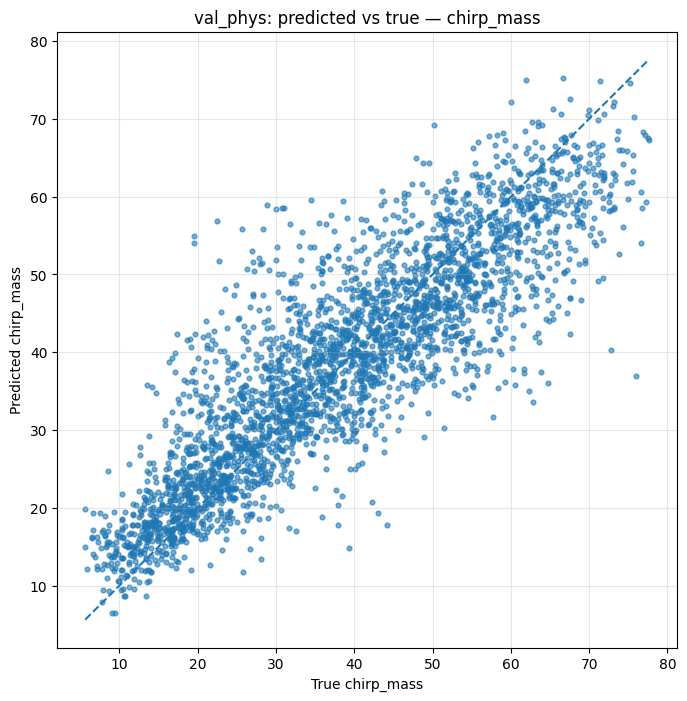

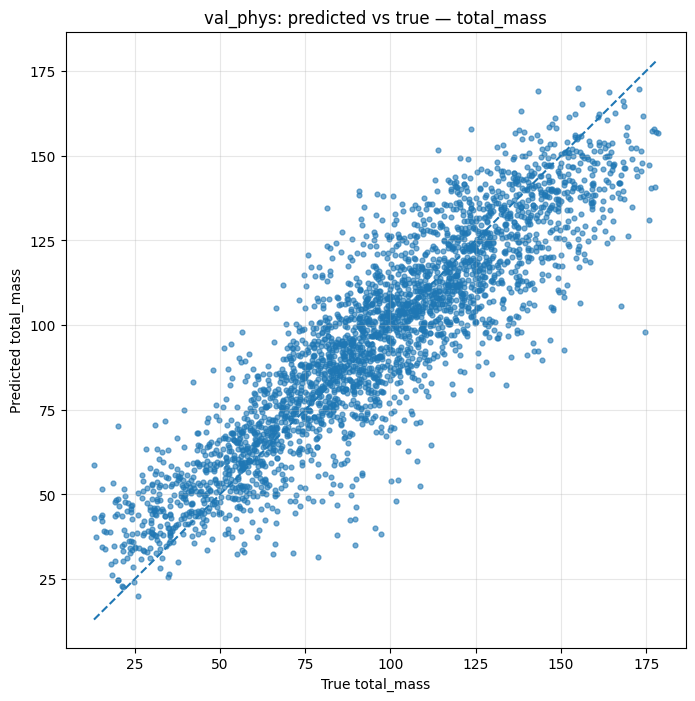

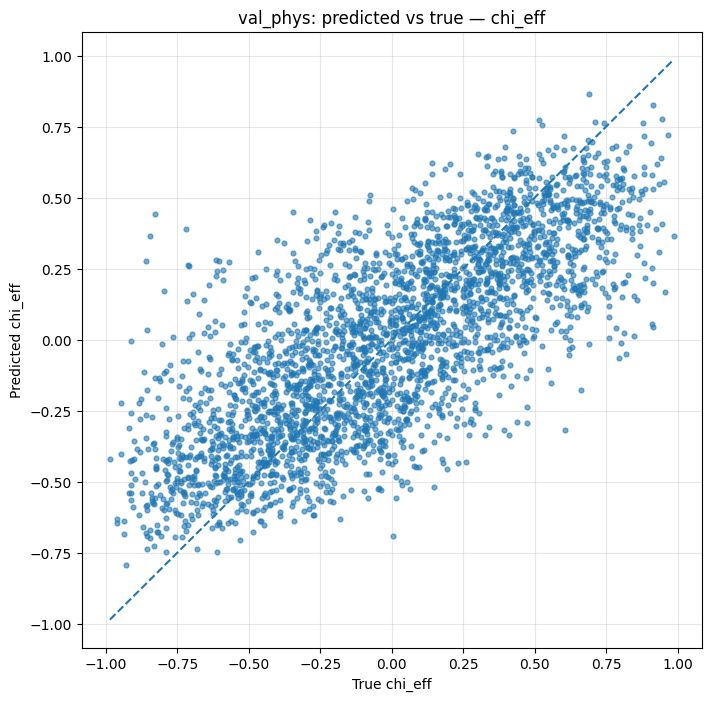

In [22]:
plot_pred_vs_true(
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    split_name="val_phys"
)

## 3. Residuals per label

In [23]:
def plot_residuals(y_true, y_pred, label_names, split_name="test"):
    residual = y_pred - y_true

    for j, label in enumerate(label_names):
        plt.figure(figsize=(6, 4))
        plt.hist(residual[:, j], bins=40, alpha=0.8)
        plt.axvline(0.0, linestyle="--")
        plt.xlabel(f"Residual: pred - true ({label})")
        plt.ylabel("Count")
        plt.title(f"{split_name}: residual distribution — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

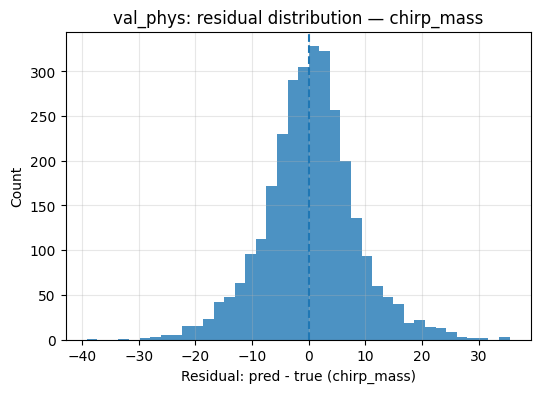

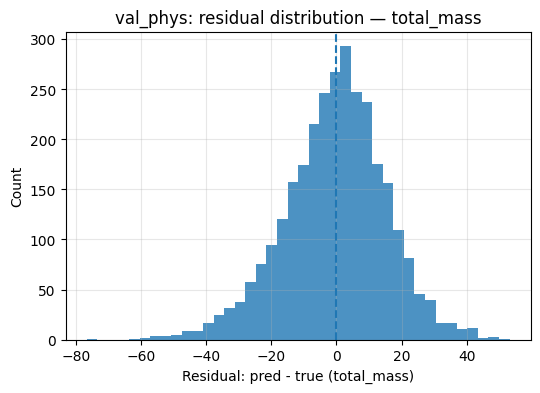

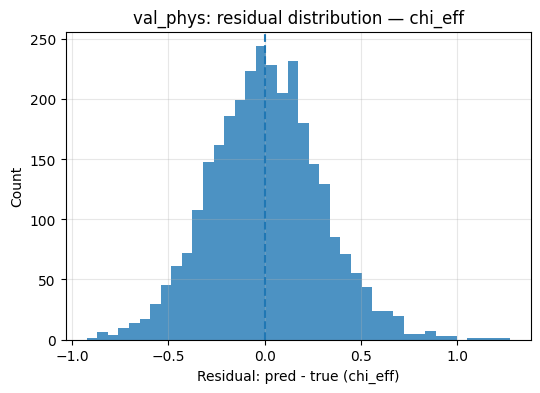

In [26]:
plot_residuals(y_val_phys, pred_val_phys, label_names, "val_phys")

In [25]:
def plot_residual_vs_true(y_true, y_pred, label_names, split_name="test"):
    residual = y_pred - y_true

    for j, label in enumerate(label_names):
        plt.figure(figsize=(6, 4))
        plt.scatter(y_true[:, j], residual[:, j], s=12, alpha=0.6)
        plt.axhline(0.0, linestyle="--")
        plt.xlabel(f"True {label}")
        plt.ylabel(f"Residual: pred - true")
        plt.title(f"{split_name}: residual vs true — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

Esto es más importante que el histograma. Te dirá dónde falla el modelo.

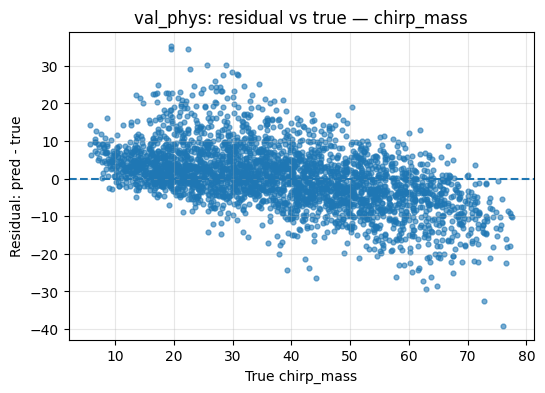

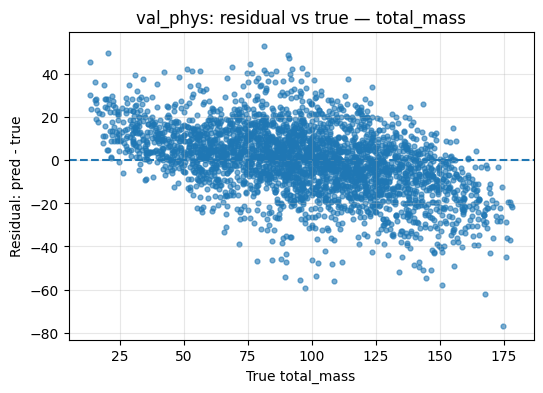

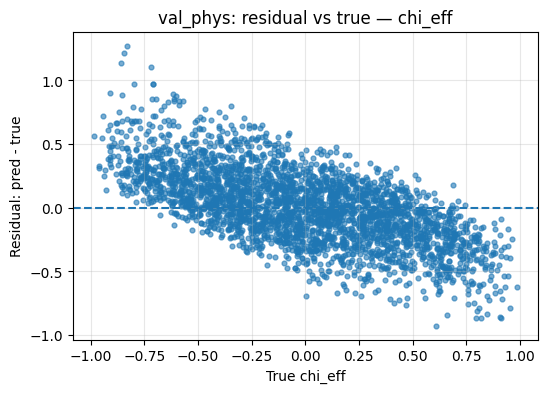

In [27]:
plot_residual_vs_true(y_val_phys, pred_val_phys, label_names, "val_phys")

## 4. Absolute error vs true value

Este plot es clave para Mondrian. Si el error aumenta con masa o depende de chi_eff, entonces tiene sentido usar bins condicionados.

In [28]:
def plot_abs_error_vs_true(y_true, y_pred, label_names, split_name="test"):
    abs_error = np.abs(y_pred - y_true)

    for j, label in enumerate(label_names):
        plt.figure(figsize=(6, 4))
        plt.scatter(y_true[:, j], abs_error[:, j], s=12, alpha=0.6)
        plt.xlabel(f"True {label}")
        plt.ylabel(f"Absolute error")
        plt.title(f"{split_name}: absolute error vs true — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

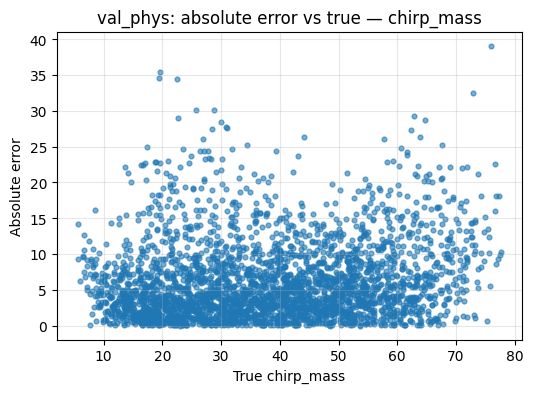

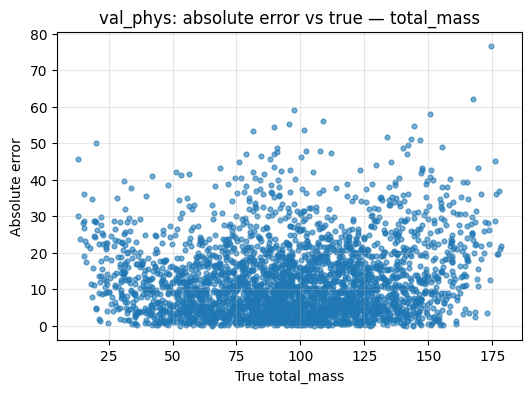

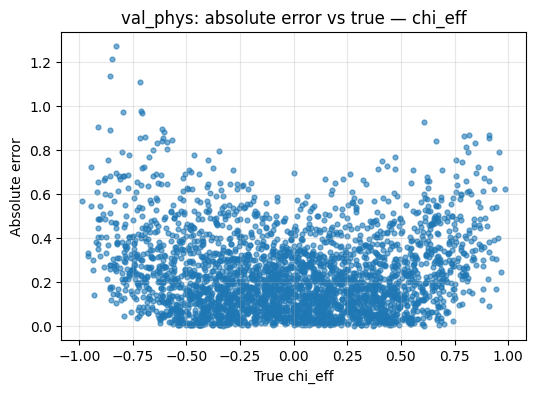

In [29]:
plot_abs_error_vs_true(y_val_phys, pred_val_phys, label_names, "val_phys")

## 5. Error vs SNR

In [30]:
snr_val = network_snrs[val_idx]

In [31]:
def plot_abs_error_vs_quantity(quantity, y_true, y_pred, label_names, quantity_name, split_name="val"):
    abs_error = np.abs(y_pred - y_true)

    for j, label in enumerate(label_names):
        plt.figure(figsize=(6, 4))
        plt.scatter(quantity, abs_error[:, j], s=12, alpha=0.6)
        plt.xlabel(quantity_name)
        plt.ylabel(f"Absolute error in {label}")
        plt.title(f"{split_name}: abs error vs {quantity_name} — {label}")
        plt.grid(True, alpha=0.3)
        plt.show()

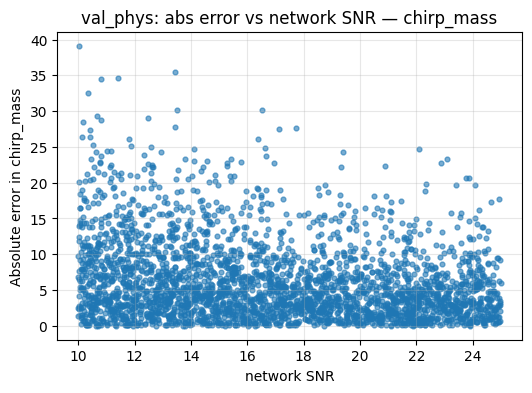

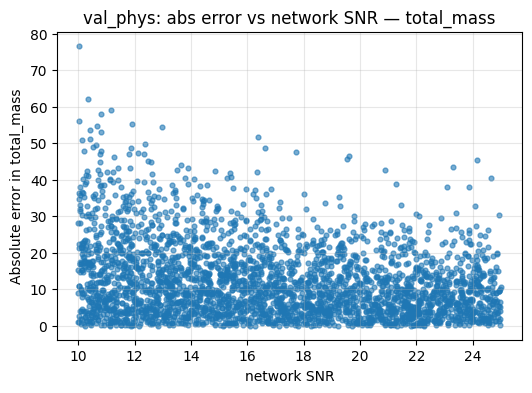

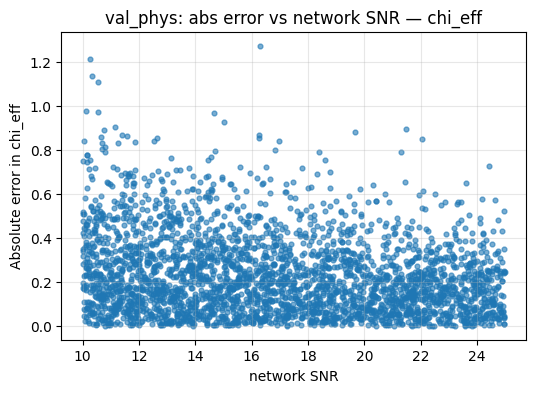

In [32]:
plot_abs_error_vs_quantity(
    quantity=snr_val,
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    quantity_name="network SNR",
    split_name="val_phys"
)

For bins

In [33]:
def metrics_by_quantity_bins(quantity, y_true, y_pred, label_names, bin_edges, quantity_name):
    rows = []

    for b in range(len(bin_edges) - 1):
        lo = bin_edges[b]
        hi = bin_edges[b + 1]

        mask = (quantity >= lo) & (quantity < hi)

        if mask.sum() == 0:
            continue

        residual = y_pred[mask] - y_true[mask]
        abs_error = np.abs(residual)

        for j, label in enumerate(label_names):
            rows.append({
                "quantity": quantity_name,
                "bin": f"[{lo:.2f}, {hi:.2f})",
                "count": int(mask.sum()),
                "label": label,
                "MAE": abs_error[:, j].mean(),
                "RMSE": np.sqrt((residual[:, j] ** 2).mean()),
                "bias": residual[:, j].mean(),
                "median_abs_error": np.median(abs_error[:, j]),
            })

    return pd.DataFrame(rows)

In [34]:


snr_edges = np.linspace(10, 25, 7)

metrics_snr_val = metrics_by_quantity_bins(
    quantity=snr_val,
    y_true=y_val_phys,
    y_pred=pred_val_phys,
    label_names=label_names,
    bin_edges=snr_edges,
    quantity_name="network_snr"
)


snr_by_label = metrics_snr_val.sort_values(by="label", kind="stable")


display(snr_by_label)

,quantity,bin,count,label,MAE,RMSE,bias,median_abs_error
2,network_snr,"[10.00, 12.50)",607,chi_eff,0.282290,0.353326,-0.011989,0.232917
5,network_snr,"[12.50, 15.00)",568,chi_eff,0.253985,0.316239,0.003503,0.218208
8,network_snr,"[15.00, 17.50)",519,chi_eff,0.229719,0.288585,-0.005143,0.199603
11,network_snr,"[17.50, 20.00)",453,chi_eff,0.211008,0.264496,0.037340,0.176829
14,network_snr,"[20.00, 22.50)",452,chi_eff,0.180169,0.229142,0.012106,0.149549
17,network_snr,"[22.50, 25.00)",401,chi_eff,0.180629,0.224668,0.018749,0.160386
0,network_snr,"[10.00, 12.50)",607,chirp_mass,8.074795,10.463397,-1.142191,6.711330
3,network_snr,"[12.50, 15.00)",568,chirp_mass,6.983302,9.031032,0.728456,5.208106
6,network_snr,"[15.00, 17.50)",519,chirp_mass,6.064643,7.958092,0.658459,4.919876
9,network_snr,"[17.50, 20.00)",453,chirp_mass,5.236703,6.786727,1.155058,4.015148


## 6. Save predictions and embeddings

In [27]:
output_path = RESULTS_DIR / f"{checkpoint_id}_predictions_embeddings.npz"

np.savez(
    output_path,

    pred_train=pred_train,
    pred_val=pred_val,
    pred_cal=pred_cal,
    pred_test=pred_test,

    y_train=y_train,
    y_val=y_val,
    y_cal=y_cal,
    y_test=y_test,

    pred_train_phys=pred_train_phys,
    pred_val_phys=pred_val_phys,
    pred_cal_phys=pred_cal_phys,
    pred_test_phys=pred_test_phys,

    y_train_phys=y_train_phys,
    y_val_phys=y_val_phys,
    y_cal_phys=y_cal_phys,
    y_test_phys=y_test_phys,

    emb_train=emb_train,
    emb_val=emb_val,
    emb_cal=emb_cal,
    emb_test=emb_test,

    idx_train=train_idx,
    idx_val=val_idx,
    idx_cal=cal_idx,
    idx_test=test_idx,

    y_mean=y_mean,
    y_std=y_std,

    label_names=np.array(label_names),

    best_epoch=checkpoint["epoch"],
    best_val_loss=checkpoint["best_val_loss"],
    checkpoint_path=str(checkpoint_path),
)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n4500_MSELoss_emb64_Pool8_predictions_embeddings.npz
